# 260530 — data-version comparison (concise template)

Drop-in template for comparing N ViT-MAE checkpoints that differ in **dataset version** (e.g. `subset_xray_only`, `subset_n`, augmentation knobs, alignment fix). Edit `RUNS` in cell 2 with your run paths; the rest auto-adapts to whatever `input_mode` / `n_in_channels` each ckpt was trained with.

Outputs
1. **Per-run config dump** — epoch, dataset subset, input layout (so you can see the data-version difference at a glance).
2. **Metrics table** — atom MSE (on/off) and density MSE on the same masked voxels of the same val sample.
3. **Single consolidated figure** — 2 rows (atom-sum / density) × (N+2) cols (GT | masked | per-run predictions) on `SLICE_AXIS`.

In [8]:
# ── imports ─────────────────────────────────────────────────────
import sys
VOX_ROOT = '/home/shpark/prj-denovo/VoxBind'
if VOX_ROOT not in sys.path:
    sys.path.insert(0, VOX_ROOT)

import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

from voxbind.models.density_vit import DensityViTMAE
from voxbind.dataset.crossdocked_xray import DatasetCrossDockedXray
from voxbind.voxelizer import Voxelizer

device = torch.device('cuda:4' if torch.cuda.is_available() else 'cpu')
torch.set_grad_enabled(False)
print('device:', device)

device: cuda:4


In [9]:
# ── edit this dict ───────────────────────────────────────────────
# Map a short label → exp dir (the directory containing checkpoint.pth.tar).
# Order in the dict = column order in plots. All runs stay on the same
# 78k xray-available data pool; only the data preprocessing 'version' changes.
RUNS = {
    'data v1': f'{VOX_ROOT}/voxbind/exps/260530_atomblob_merged_density_vit_mae_40m_weighted_pretrain',     # original crops + normalize=true
    'data v2': f'{VOX_ROOT}/voxbind/exps/260530_atomblob_merged_density_vit_mae_40m_weighted_v2_pretrain',  # xray_crops_aligned_v2 + normalize=false
    'data v3': f'{VOX_ROOT}/voxbind/exps/260530_atomblob_merged_density_vit_mae_40m_weighted_v3_pretrain',  # xray_crops_aligned_v3 + normalize=false
}

# Sample + mask knobs (kept identical across runs for an apples-to-apples comparison)
SAMPLE_IDX   = 60         # has lig with F+Cl (diverse rare elements)
SLICE_AXIS   = 'z'        # 'x' | 'y' | 'z'
SLICE_OFFSET = 0
SEED_MASK    = 0
BLOCK_SIZE   = 8
MASK_RATIO   = 0.60
GRID_DIM     = 64
RESOLUTION   = 0.25
POS_THRESH   = 0.05
DATA_DIR  = f'{VOX_ROOT}/voxbind/dataset/data'
CROPS_DIR = f'{DATA_DIR}/xray_crops_aligned'
print(f'{len(RUNS)} run(s): {list(RUNS.keys())}')

3 run(s): ['data v1', 'data v2', 'data v3']


In [10]:
# ── load each model + extract its data-version metadata ──────────
def load_run(exp_dir):
    ckpt = torch.load(f'{exp_dir}/checkpoint.pth.tar', map_location=device, weights_only=False)
    cfg = ckpt['cfg']
    model = DensityViTMAE(
        grid_dim=int(cfg.vox.grid_dim),
        patch_size=int(cfg.model.patch_size),
        n_in_channels=int(cfg.model.n_in_channels),
        n_channels=int(cfg.model.n_channels),
        dim=int(cfg.model.dim),
        depth=int(cfg.model.depth),
        n_heads=int(cfg.model.heads),
        mlp_ratio=int(cfg.model.mlp_ratio),
        dropout=float(cfg.model.dropout),
        n_struct_channels=int(cfg.model.n_struct_channels),
    ).to(device).eval()
    sd = ckpt.get('state_dict_ema', ckpt.get('state_dict'))
    sd = {k.replace('module.', '').replace('_orig_mod.', ''): v for k, v in sd.items()}
    miss, unexp = model.load_state_dict(sd, strict=False)
    assert len(miss) == 0 and len(unexp) == 0
    return {
        'model': model,
        'epoch': ckpt.get('epoch'),
        'input_mode': str(cfg.get('input_mode', 'density')),
        'n_in':     int(cfg.model.n_in_channels),
        'subset_n': cfg.dset.get('subset_n', None),
        'subset_xray_only': cfg.dset.get('subset_xray_only', False),
        'use_xray':         cfg.dset.get('use_xray', False),
        'density_source':   str(cfg.mae.get('density_source', 'synthetic')),
        'crops_dir':        str(cfg.dset.get('crops_dir', '')),
        'normalize':        bool(cfg.dset.get('normalize', True)),
    }

runs = {label: load_run(p) for label, p in RUNS.items()}
print(f'{"label":<12} {"epoch":>5}  {"input_mode":<25} {"n_in":>4}  {"subset_n":>8}  '
      f'{"crops_dir":<30}  {"normalize":<9}')
for label, r in runs.items():
    crops_name = r['crops_dir'].split('/')[-1] if r['crops_dir'] else '-'
    print(f'{label:<12} {r["epoch"]:>5}  {r["input_mode"]:<25} {r["n_in"]:>4}  '
          f'{str(r["subset_n"]):>8}  {crops_name:<30}  {str(r["normalize"]):<9}')

label        epoch  input_mode                n_in  subset_n  crops_dir                       normalize
data v1         99  atomblob_merged_density      8     78428  xray_crops_aligned              True     
data v2         99  atomblob_merged_density      8     78428  xray_crops_aligned_v2           False    
data v3         99  atomblob_merged_density      8     78428  xray_crops_aligned_v3           False    


In [11]:
# ── load val sample + voxelize atoms (shared across versions) ───────
# Atom coords are identical across data versions (same data_dir, only crops_dir
# differs). So we voxelize lig/poc ONCE here. Density is loaded per-run below
# because each version has its own xray_crops_aligned_v* directory.
dset_v1 = DatasetCrossDockedXray(
    data_dir=DATA_DIR, crops_dir=CROPS_DIR,
    split='val', aug=False, small=False,
    ligand_radius=0.5, pocket_radius=-1,
    use_xray=True, normalize=True,
    subset_xray_only=True, subset_n=78428, subset_val_n=100,
)
sample = dset_v1[SAMPLE_IDX]
print(f'sample id: {sample["ligand"]["id"]}')

voxelizer = Voxelizer(grid_dim=GRID_DIM, resolution=RESOLUTION, cubes_around=8, device=device)
lig = {k: sample['ligand'][k].unsqueeze(0).to(device) for k in ('coords', 'radius', 'atoms_channel')}
poc = {k: sample['pocket'][k].unsqueeze(0).to(device) for k in ('coords', 'radius', 'atoms_channel')}
v_lig = voxelizer(lig, num_channels=7)
v_poc = voxelizer(poc, num_channels=4)
v_merged = v_lig.clone(); v_merged[:, :4] += v_poc                       # (1, 7, G³)

# Per-run density: re-instantiate the dataset with each run's crops_dir +
# normalize flag so the density tensor matches what that model was trained on.
def load_density_for_run(crops_dir, normalize_flag):
    dset = DatasetCrossDockedXray(
        data_dir=DATA_DIR, crops_dir=crops_dir,
        split='val', aug=False, small=False,
        ligand_radius=0.5, pocket_radius=-1,
        use_xray=True, normalize=normalize_flag,
        subset_xray_only=True, subset_n=78428, subset_val_n=100,
    )
    return dset[SAMPLE_IDX]['xray_density'].unsqueeze(0).unsqueeze(0).to(device)

for label, r in runs.items():
    r['d_xray'] = load_density_for_run(r['crops_dir'], r['normalize'])
    crops_name = r['crops_dir'].split('/')[-1]
    d = r['d_xray']
    print(f'{label:<10}  crops={crops_name:<28}  normalize={str(r["normalize"]):<5}  '
          f'density mean={d.mean().item():+.3f}  std={d.std().item():.3f}  '
          f'range=[{d.min().item():+.2f}, {d.max().item():+.2f}]')

# Shared block mask
g = torch.Generator(device=device).manual_seed(SEED_MASK)
blocks = torch.rand(1, 1, GRID_DIM // BLOCK_SIZE, GRID_DIM // BLOCK_SIZE, GRID_DIM // BLOCK_SIZE,
                    device=device, generator=g) < MASK_RATIO
mask = blocks.repeat_interleave(BLOCK_SIZE, 2).repeat_interleave(BLOCK_SIZE, 3).repeat_interleave(BLOCK_SIZE, 4)
print(f'\nmask fraction: {mask.float().mean().item():.3f} (target {MASK_RATIO})')

# 11-channel atom GT (shared); per-run density GT lives in runs[label]['d_xray']
x_atoms_gt = torch.cat([v_lig, v_poc], dim=1)                            # (1, 11)

sample id: FA10_HUMAN_126_476_0/2p94_L_rec_2vwl_lzh_lig_tt_docked_0.sdf
data v1     crops=xray_crops_aligned            normalize=True   density mean=-0.007  std=0.974  range=[-2.75, +3.00]
data v2     crops=xray_crops_aligned_v2         normalize=False  density mean=+0.013  std=0.998  range=[-2.73, +8.01]
data v3     crops=xray_crops_aligned_v3         normalize=False  density mean=+0.000  std=0.009  range=[-0.03, +0.08]

mask fraction: 0.580 (target 0.6)


In [12]:
# ── forward each model on the matching clean input + mask ──────────
# Build x_clean per run with its OWN density crop (each model trained on a
# different density preprocessing version).
def build_x_clean(input_mode, d):
    if input_mode == 'atomblob':                  return torch.cat([v_lig, v_poc], dim=1)
    if input_mode == 'atomblob_density':          return torch.cat([v_lig, v_poc, d], dim=1)
    if input_mode == 'atomblob_merged':           return v_merged
    if input_mode == 'atomblob_merged_density':   return torch.cat([v_merged, d], dim=1)
    if input_mode == 'density':                   return d
    raise ValueError(input_mode)

def split_output(out, input_mode):
    """Return (atom_sum, density_or_None) so plotting is mode-agnostic."""
    if input_mode == 'density':                  return None, out[0, 0]
    if input_mode == 'atomblob':                 return out[0, :11].sum(0), None
    if input_mode == 'atomblob_density':         return out[0, :11].sum(0), out[0, 11]
    if input_mode == 'atomblob_merged':          return out[0, :7].sum(0), None
    if input_mode == 'atomblob_merged_density':  return out[0, :7].sum(0), out[0, 7]
    raise ValueError(input_mode)

for label, r in runs.items():
    x_clean = build_x_clean(r['input_mode'], r['d_xray'])
    x_in    = x_clean * (~mask).to(x_clean.dtype)
    out, _  = r['model'](x_in)
    r['atom_sum'], r['density'] = split_output(out, r['input_mode'])
    r['out_shape'] = tuple(out.shape)
    print(f'{label:<10}  out={r["out_shape"]}  '
          f'has_atoms={r["atom_sum"] is not None}  has_density={r["density"] is not None}')

data v1     out=(1, 8, 64, 64, 64)  has_atoms=True  has_density=True
data v2     out=(1, 8, 64, 64, 64)  has_atoms=True  has_density=True
data v3     out=(1, 8, 64, 64, 64)  has_atoms=True  has_density=True


In [13]:
# ── metrics table: atom MSE@on/off + density MSE on the same masked voxels ──
# Atom GT is shared (same coords across versions); density GT is per-run.
m_bool = mask[0, 0].bool()
tgt_atom_sum_lig = x_atoms_gt[0, :7].sum(0)
tgt_atom_sum_poc = x_atoms_gt[0, 7:11].sum(0)
tgt_atom_sum     = tgt_atom_sum_lig + tgt_atom_sum_poc
print(f'GT atom-sum peak: {tgt_atom_sum.max().item():.3f}')
print()
print(f'{"label":<12} {"atom MSE@on":>12} {"atom MSE@off":>13} {"atom peak":>10}  '
      f'{"dens MSE":>9} {"dens MSE>1σ":>13}  {"dens GT range":>20}')
for label, r in runs.items():
    if r['atom_sum'] is not None:
        pos = tgt_atom_sum > POS_THRESH
        mse_on  = ((r['atom_sum'] - tgt_atom_sum)[pos & m_bool] ** 2).mean().item() if (pos & m_bool).any() else float('nan')
        mse_off = ((r['atom_sum'] - tgt_atom_sum)[~pos & m_bool] ** 2).mean().item()
        peak    = r['atom_sum'].max().item()
    else:
        mse_on = mse_off = peak = float('nan')
    if r['density'] is not None:
        d_gt = r['d_xray'][0, 0]
        d_mse    = ((r['density'] - d_gt)[m_bool] ** 2).mean().item()
        d_mse_hi = ((r['density'] - d_gt)[(d_gt > 1.0) & m_bool] ** 2).mean().item()
        d_range = f'[{d_gt.min().item():+.2f}, {d_gt.max().item():+.2f}]'
    else:
        d_mse = d_mse_hi = float('nan'); d_range = '-'
    print(f'{label:<12} {mse_on:>12.4f} {mse_off:>13.6f} {peak:>10.3f}  '
          f'{d_mse:>9.4f} {d_mse_hi:>13.4f}  {d_range:>20}')

GT atom-sum peak: 2.031

label         atom MSE@on  atom MSE@off  atom peak   dens MSE   dens MSE>1σ         dens GT range
data v1            0.0087      0.005292      2.165     0.0692        0.1087        [-2.75, +3.00]
data v2            0.0088      0.005952      2.146     0.0796        0.1400        [-2.73, +8.01]
data v3            0.0039      0.001040      2.040     0.0000           nan        [-0.03, +0.08]


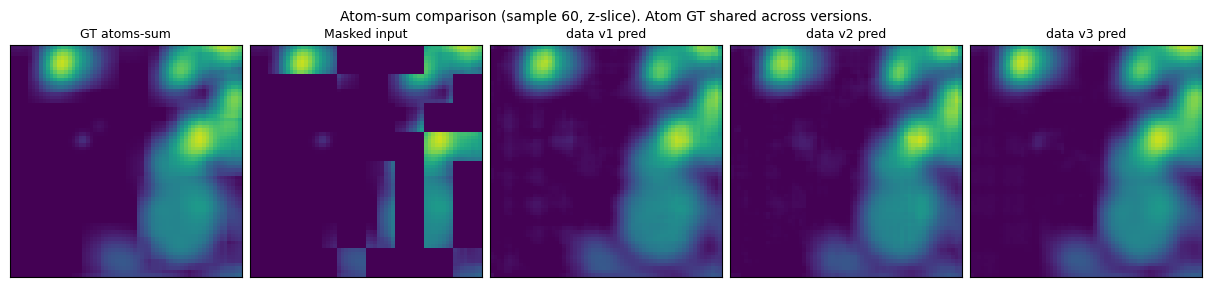

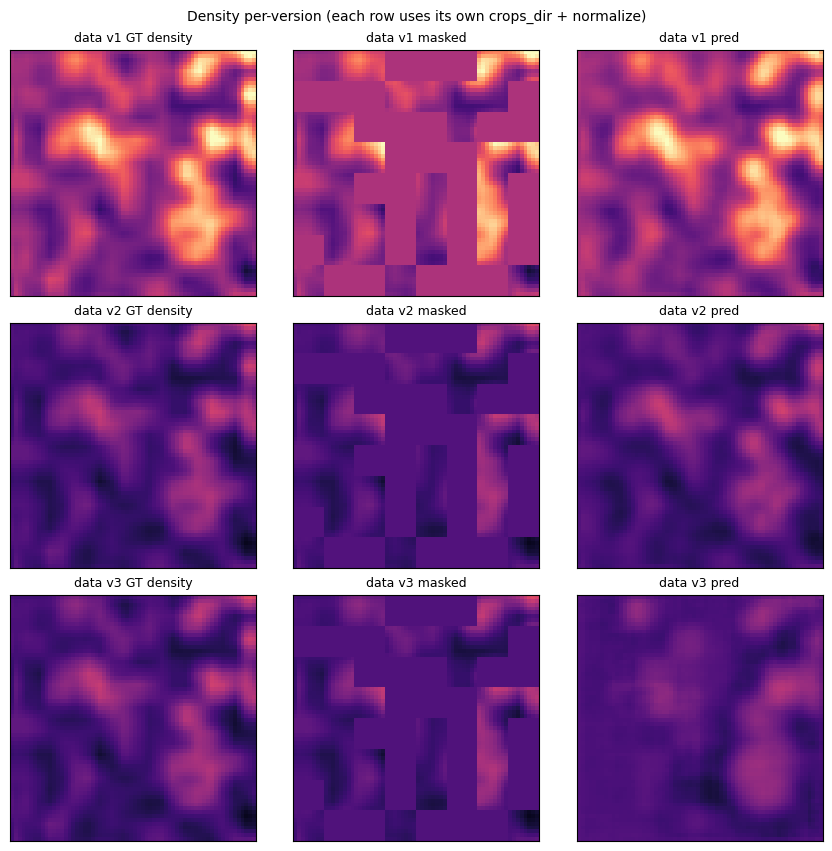

In [14]:
# ── two figures: atoms (shared GT) + density (per-run GT) ─────────
def take_slice(vol, axis='z', offset=0):
    arr = vol.detach().cpu().numpy() if torch.is_tensor(vol) else vol
    G = arr.shape[-1]
    idx = G // 2 + offset
    return {'x': arr[idx], 'y': arr[:, idx], 'z': arr[:, :, idx]}[axis]

def show(ax, img, title, cmap, vmin=None, vmax=None):
    ax.imshow(img.T, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

# ── Fig 1: atoms — shared GT, shared masked input, then per-run preds
atom_cols = [('GT atoms-sum', tgt_atom_sum, 'viridis'),
             ('Masked input', tgt_atom_sum * (~m_bool).float(), 'viridis')]
for label, r in runs.items():
    if r['atom_sum'] is not None:
        atom_cols.append((f'{label} pred', r['atom_sum'], 'viridis'))
    else:
        atom_cols.append((f'{label} (no atoms)', torch.zeros_like(tgt_atom_sum), 'gray'))

n_col_a = len(atom_cols)
vmax_a = max(float(p[1].max()) for p in atom_cols if p[2] != 'gray')
fig_a, axes_a = plt.subplots(1, n_col_a, figsize=(2.4 * n_col_a, 2.8), constrained_layout=True)
for c, (title, vol, cmap) in enumerate(atom_cols):
    show(axes_a[c], take_slice(vol, SLICE_AXIS, SLICE_OFFSET), title, cmap,
         vmin=0 if cmap != 'gray' else None, vmax=vmax_a if cmap != 'gray' else None)
fig_a.suptitle(
    f'Atom-sum comparison (sample {SAMPLE_IDX}, {SLICE_AXIS}-slice). Atom GT shared across versions.',
    fontsize=10,
)
plt.show()

# ── Fig 2: density — per-run GT + masked + pred (one row per run, 3 cols)
dens_runs = [(label, r) for label, r in runs.items() if r['density'] is not None]
if dens_runs:
    fig_d, axes_d = plt.subplots(len(dens_runs), 3, figsize=(8.5, 2.8 * len(dens_runs)),
                                  constrained_layout=True, squeeze=False)
    for row, (label, r) in enumerate(dens_runs):
        d_gt = r['d_xray'][0, 0]
        vlo, vhi = d_gt.min().item(), d_gt.max().item()
        show(axes_d[row, 0], take_slice(d_gt,                                 SLICE_AXIS, SLICE_OFFSET),
             f'{label} GT density', 'magma', vmin=vlo, vmax=vhi)
        show(axes_d[row, 1], take_slice(d_gt * (~m_bool).float(),             SLICE_AXIS, SLICE_OFFSET),
             f'{label} masked',     'magma', vmin=vlo, vmax=vhi)
        show(axes_d[row, 2], take_slice(r['density'],                         SLICE_AXIS, SLICE_OFFSET),
             f'{label} pred',       'magma', vmin=vlo, vmax=vhi)
    fig_d.suptitle('Density per-version (each row uses its own crops_dir + normalize)', fontsize=10)
    plt.show()

## Notes

* Cell 2 is the only place to edit when adding/removing runs. Everything downstream auto-adapts to the per-ckpt `input_mode` / `n_in_channels`.
* All runs share the same val sample, voxelization, and block mask (`SEED_MASK`) — differences in the figures/table are pure model-effects.
* For runs without a density head (`atomblob`, `atomblob_merged`), the density-row entry is shown as a gray placeholder so column ordering stays aligned with the atom row.
* Metrics are computed on the **shared 11-channel atom GT** summed across channels and on the real X-ray density crop; comparable across runs regardless of their individual channel layouts.